# Análisis de Perfil i Desempeño Professional

**Desafío 1**  
Quin és el perfil sociodemogràfic dels empleats que tenim a l'empresa, i com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional?

*Punts a respondre (dibuix de la pregunta)* 
- Perfil sociodemogràfic (Columnes: 'ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated')
- Com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional (valorar les altres variables no demogràfiques (e.g. 'Absenteeism_hours', hit target (comparativa)) o simplement fer-ho de forma teòrica?)

## Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Documentos

In [2]:
DATA_INPUT_FILE = '../../Data/clean/clean_data_25052026.csv'

In [3]:
df = pd.read_csv(DATA_INPUT_FILE)

In [4]:
df.sample(5)

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
661,3,28.0,Consulta dental,12.0,Diciembre,6,Viernes,2,Primavera,179,...,Secundaria,0,1,0,0,89,170,31,30.8,1
13,20,19.0,"Lesiones, intoxicaciones y consecuencias externas",4.0,Abril,6,Viernes,4,Otoño,260,...,Secundaria,4,1,0,0,65,168,23,23.0,56
290,15,23.0,Consulta médica,9.0,Septiembre,5,Jueves,1,Invierno,291,...,Secundaria,1,1,0,1,73,171,25,25.0,4
538,15,28.0,Consulta dental,11.0,Noviembre,4,Miércoles,2,Primavera,291,...,Secundaria,1,1,0,1,73,171,25,25.0,2
251,5,26.0,Ausencia injustificada,5.0,Mayo,4,Miércoles,4,Otoño,235,...,Secundaria,1,1,0,0,106,167,38,38.0,8


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Reason_absence           697 non-null    float64
 2   Reason_absence_name      697 non-null    str    
 3   Month_absence            737 non-null    float64
 4   Month_absence_name       737 non-null    str    
 5   Day_week                 740 non-null    int64  
 6   Day_week_name            740 non-null    str    
 7   Seasons                  740 non-null    int64  
 8   Seasons_name             740 non-null    str    
 9   Transportation_expense   740 non-null    int64  
 10  Distance_Residence_Work  740 non-null    int64  
 11  Service_time             740 non-null    int64  
 12  Age                      740 non-null    int64  
 13  Work_load_Average_day    740 non-null    float64
 14  Hit_target               740 non-null

In [6]:
df.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours'],
      dtype='str')

## Viz

### Perfil sociodemogràfic

In [7]:
perfil_col = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated']

In [8]:
df_perfil = df.loc[:, perfil_col]
df_perfil.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated
568,28,225,26,9,28,1,Secundaria,1,0,0,2,69,169,24.2
414,22,179,26,9,30,3,Posgrado,0,0,0,0,56,171,19.2
525,24,246,25,16,41,1,Secundaria,0,1,0,0,67,170,23.2
444,28,225,26,9,28,1,Secundaria,1,0,0,2,69,169,24.2
698,28,225,26,9,28,1,Secundaria,1,0,0,2,69,169,24.2


In [9]:
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Transportation_expense   740 non-null    int64  
 2   Distance_Residence_Work  740 non-null    int64  
 3   Service_time             740 non-null    int64  
 4   Age                      740 non-null    int64  
 5   Education                740 non-null    int64  
 6   Education_name           740 non-null    str    
 7   Son                      740 non-null    int64  
 8   Social_drinker           740 non-null    int64  
 9   Social_smoker            740 non-null    int64  
 10  Pet                      740 non-null    int64  
 11  Weight                   740 non-null    int64  
 12  Height                   740 non-null    int64  
 13  BMI_calculated           740 non-null    float64
dtypes: float64(1), int64(12), str(1)
memo

In [10]:
df_perfil.duplicated().sum()

np.int64(704)

In [11]:
df_perfil.drop_duplicates(inplace=True)

In [12]:
df_perfil.shape

(36, 14)

In [13]:
df_perfil.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36.0,18.500000,10.535654,1.0,9.75,18.5,27.250,36.0
Transportation_expense,36.0,237.277778,73.982087,118.0,179.00,235.0,289.000,388.0
Distance_Residence_Work,36.0,27.194444,14.520566,5.0,15.00,25.5,37.500,52.0
Service_time,36.0,12.388889,5.309171,1.0,9.00,13.0,14.000,29.0
Age,36.0,38.333333,7.917431,27.0,32.00,37.5,43.000,58.0
Education,36.0,1.361111,0.761682,1.0,1.00,1.0,1.000,4.0
Son,36.0,1.138889,1.018480,0.0,0.00,1.0,2.000,4.0
Social_drinker,36.0,0.527778,0.506309,0.0,0.00,1.0,1.000,1.0
Social_smoker,36.0,0.194444,0.401386,0.0,0.00,0.0,0.000,1.0
Pet,36.0,1.277778,2.092314,0.0,0.00,0.0,2.000,8.0


In [14]:
for col in perfil_col:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-----')

ID
36
[14 36  9 28 11 13 34 22 26 20 10 15 17 24  3 18  7  1 30  5  6  2 31 27
 33 23 21 25 12 32 16 29 19  8  4 35]
-----
Transportation_expense
24
[155 118 228 225 289 369 179 300 260 361 291 246 330 279 235 157 189 388
 184 248 378 268 233 231]
-----
Distance_Residence_Work
25
[12 13 14 26 36 17 10 50 52 31 22 25 51 16  5 11 27 20 29 15 42 49 48 35
 45]
-----
Service_time
18
[14 18 16  9 13 12 10 11  3 17  4  6  7  8  1 29 24 15]
-----
Age
22
[34 50 58 28 33 31 37 30 43 36 40 41 38 39 29 48 27 47 32 49 46 53]
-----
Education
4
[1 3 2 4]
-----
Education_name
4
<StringArray>
['Secundaria', 'Posgrado', 'Grado', 'Máster/Doctorado']
Length: 4, dtype: str
-----
Son
5
[2 1 3 0 4]
-----
Social_drinker
2
[1 0]
-----
Social_smoker
2
[0 1]
-----
Pet
6
[0 1 2 4 5 8]
-----
Weight
26
[ 95  98  65  69  90  70  83  56  77  80  73  63  67  89  84  68  88  75
 106  76  58  86  79 108  94 100]
-----
Height
14
[196 178 172 169 171 175 168 170 182 185 167 163 165 174]
-----
BMI_calculated
32
[24.7 30.9 

ID


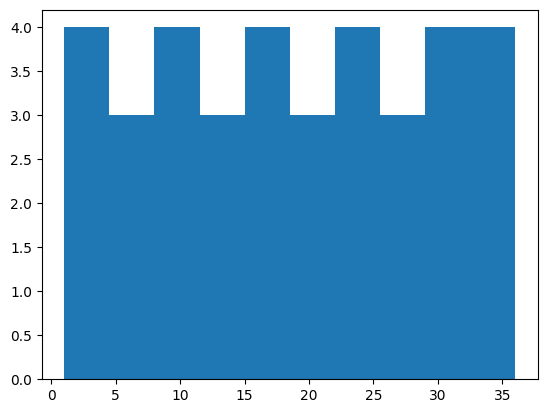

-----
Transportation_expense


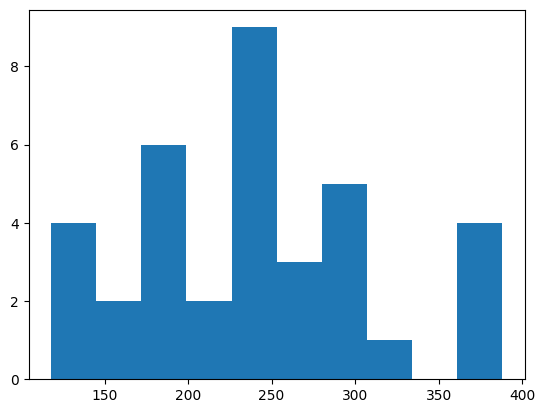

-----
Distance_Residence_Work


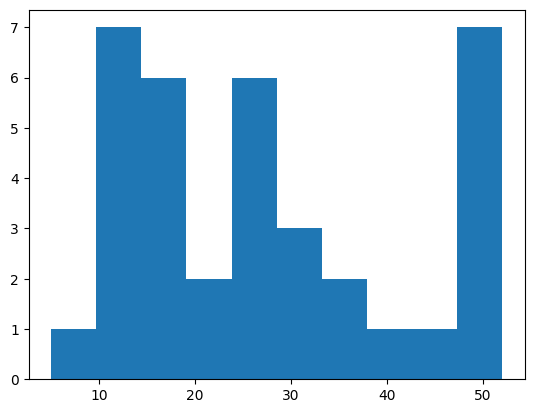

-----
Service_time


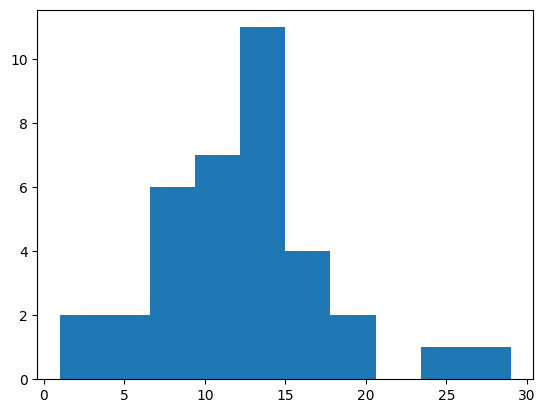

-----
Age


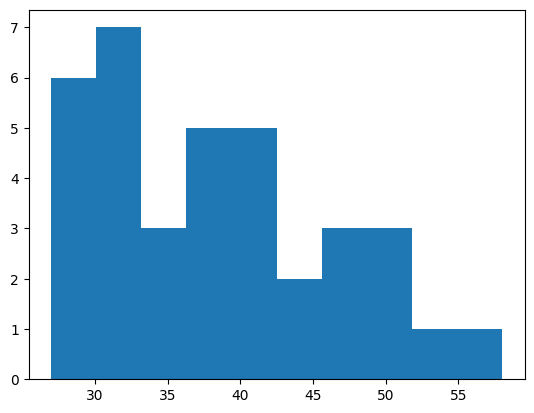

-----
Education


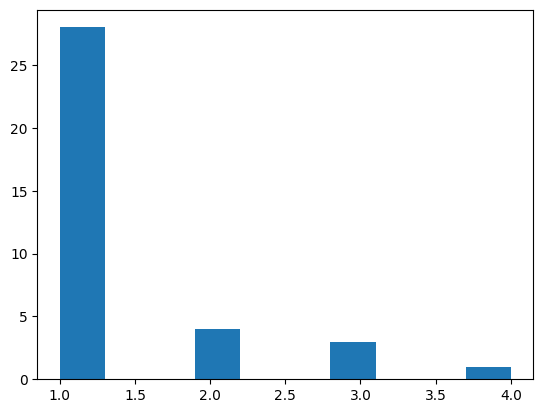

-----
Education_name


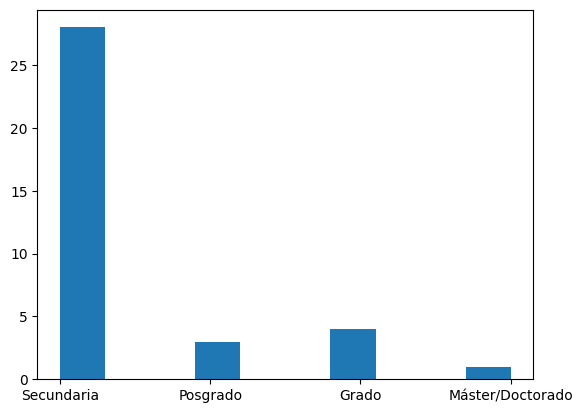

-----
Son


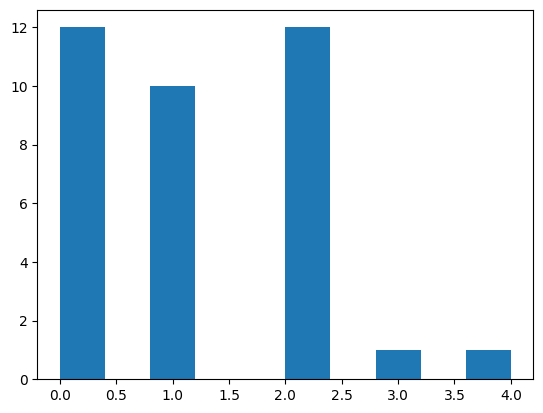

-----
Social_drinker


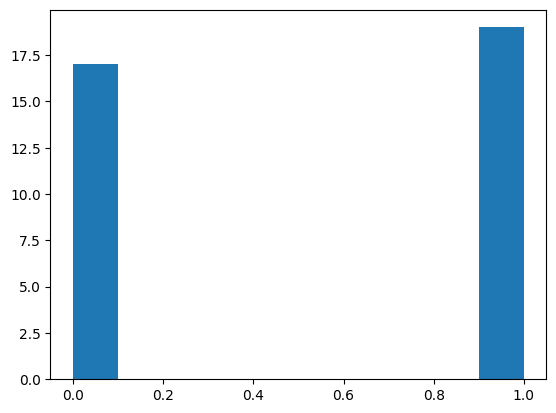

-----
Social_smoker


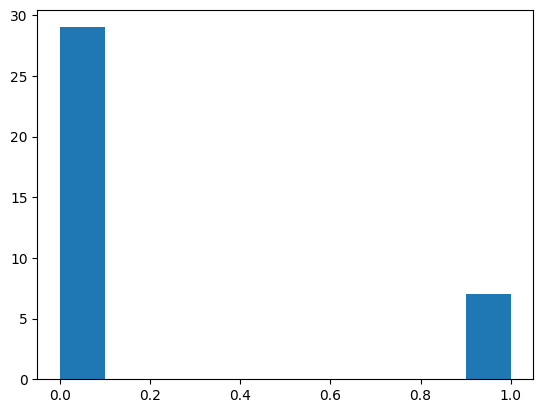

-----
Pet


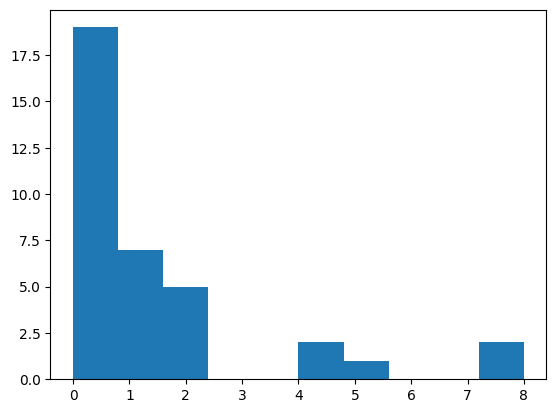

-----
Weight


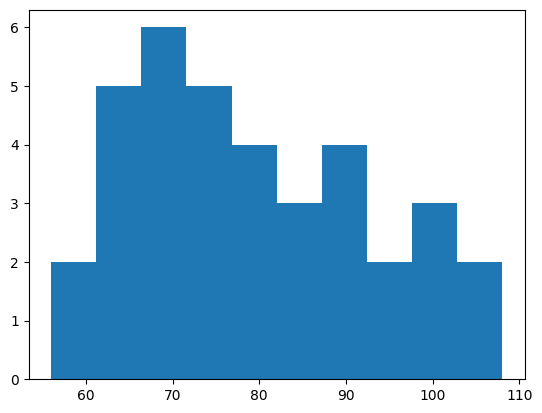

-----
Height


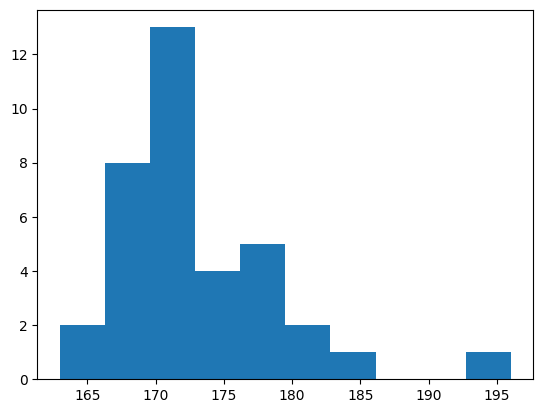

-----
BMI_calculated


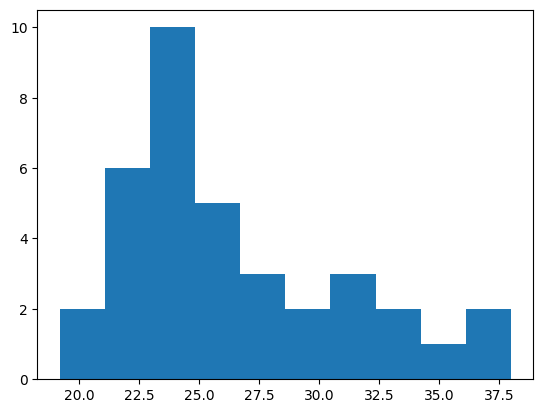

-----


In [15]:
for col in perfil_col:
    print(col)
    plt.hist(df_perfil[col])
    plt.show()
    print('-----')

## PERFIL PROMEDIO DEL TRABAJADOR

In [16]:
df_empleados = df.drop_duplicates(subset='ID').copy()

In [17]:
df_empleados.duplicated().sum()

np.int64(0)

In [18]:
df_empleados.drop_duplicates(inplace=True)

In [19]:
df_empleados.shape

(36, 27)

In [20]:
df_empleados.head(10)

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
0,14,11.0,Sistema digestivo,11.0,Noviembre,2,Lunes,2,Primavera,155,...,Secundaria,2,1,0,0,95,196,25,24.7,120
1,36,13.0,Sistema musculoesquelético,4.0,Abril,4,Miércoles,4,Otoño,118,...,Secundaria,1,1,0,0,98,178,31,30.9,120
2,9,6.0,Sistema nervioso,7.0,Julio,3,Martes,1,Invierno,228,...,Secundaria,2,0,0,1,65,172,22,22.0,120
3,28,9.0,Sistema circulatorio,7.0,Julio,3,Martes,1,Invierno,225,...,Secundaria,1,0,0,2,69,169,24,24.2,112
5,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,2,Lunes,4,Otoño,289,...,Secundaria,2,1,0,1,90,172,30,30.4,104
8,13,13.0,Sistema musculoesquelético,7.0,Julio,2,Lunes,1,Invierno,369,...,Secundaria,3,1,0,0,70,169,25,24.5,80
9,34,19.0,"Lesiones, intoxicaciones y consecuencias externas",12.0,Diciembre,3,Martes,2,Primavera,118,...,Secundaria,0,0,0,0,83,172,28,28.1,64
10,22,1.0,Enfermedades infecciosas y parasitarias,10.0,Octubre,4,Miércoles,2,Primavera,179,...,Posgrado,0,0,0,0,56,171,19,19.2,64
11,26,19.0,"Lesiones, intoxicaciones y consecuencias externas",5.0,Mayo,6,Viernes,4,Otoño,300,...,Secundaria,2,1,1,1,77,175,25,25.1,64
13,20,19.0,"Lesiones, intoxicaciones y consecuencias externas",4.0,Abril,6,Viernes,4,Otoño,260,...,Secundaria,4,1,0,0,65,168,23,23.0,56


In [21]:
perfil_num = [
    'Transportation_expense',
    'Distance_Residence_Work',
    'Service_time',
    'Age',
    'Son',
    'Pet',
    'Weight',
    'Height',
    'BMI_calculated'
]

#Media de variables numéricas
perfil_promedio = df_perfil[perfil_num].mean().round(2)

print("Perfil promedio del empleado:")
print(perfil_promedio)

Perfil promedio del empleado:
Transportation_expense     237.28
Distance_Residence_Work     27.19
Service_time                12.39
Age                         38.33
Son                          1.14
Pet                          1.28
Weight                      78.94
Height                     173.06
BMI_calculated              26.41
dtype: float64


In [22]:
print("=== PERFIL SOCIODEMOGRÁFICO ===")

print("\nEdad media:", df_perfil['Age'].mean().round(1))

print("BMI medio:", df_perfil['BMI_calculated'].mean().round(1))

print("\nEducación más frecuente:")
print(df_perfil['Education_name'].mode()[0])

print("\n% fumadores:")
print((df_perfil['Social_smoker'].mean()*100).round(1), "%")

print("\n% consumen alcohol:")
print((df_perfil['Social_drinker'].mean()*100).round(1), "%")

=== PERFIL SOCIODEMOGRÁFICO ===

Edad media: 38.3
BMI medio: 26.4

Educación más frecuente:
Secundaria

% fumadores:
19.4 %

% consumen alcohol:
52.8 %


## 1. ANALISIS RESPECTO ABSENTISMO

### Barras Absentismo

In [23]:
def comparar_absentismo(df, variable):
    resultado = (
        df.groupby(variable)['Absenteeism_hours']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='Absenteeism_hours', ascending=False)
    )

    conteo = df[variable].value_counts()

    print("\n Recuento por grupo:")
    print(conteo)

    print("\n Absentismo medio por grupo:")
    print(resultado)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=resultado,
        x=variable,
        y='Absenteeism_hours'
    )

    plt.title(f'Absentismo medio por {variable}')
    plt.ylabel('Horas promedio absentismo')
    plt.xlabel(variable)

    plt.xticks(rotation=45)

    plt.show()


 Recuento por grupo:
Education_name
Secundaria          28
Grado                4
Posgrado             3
Máster/Doctorado     1
Name: count, dtype: int64

 Absentismo medio por grupo:
     Education_name  Absenteeism_hours
3        Secundaria              39.57
2          Posgrado              29.33
0             Grado              20.00
1  Máster/Doctorado               8.00


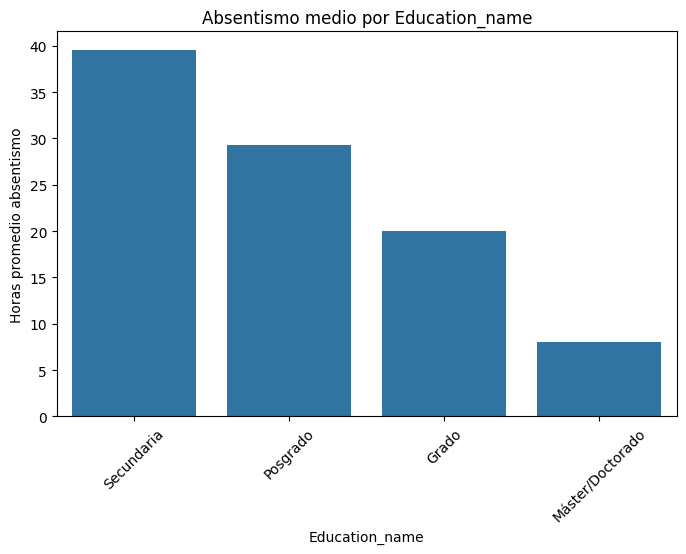

In [24]:
comparar_absentismo(df_empleados, 'Education_name')


 Recuento por grupo:
Social_smoker
0    29
1     7
Name: count, dtype: int64

 Absentismo medio por grupo:
   Social_smoker  Absenteeism_hours
0              0              38.76
1              1              22.86


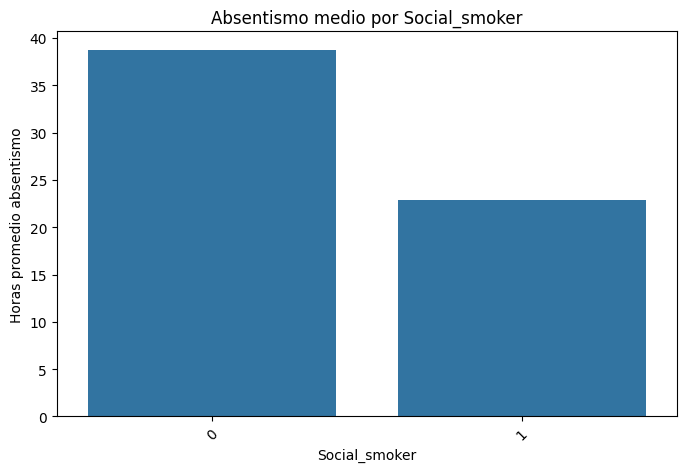

In [25]:
comparar_absentismo(df_empleados, 'Social_smoker')


 Recuento por grupo:
Social_drinker
1    19
0    17
Name: count, dtype: int64

 Absentismo medio por grupo:
   Social_drinker  Absenteeism_hours
1               1              40.21
0               0              30.59


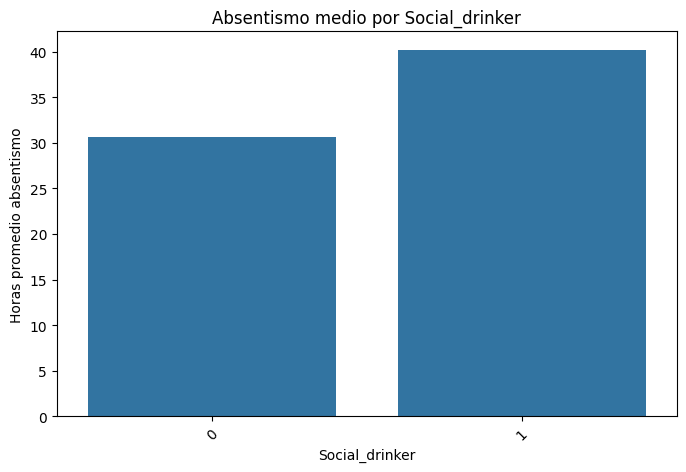

In [26]:
comparar_absentismo(df_empleados, 'Social_drinker')


 Recuento por grupo:
Son
2    12
0    12
1    10
3     1
4     1
Name: count, dtype: int64

 Absentismo medio por grupo:
   Son  Absenteeism_hours
3    3              80.00
4    4              56.00
2    2              42.67
1    1              36.00
0    0              23.00


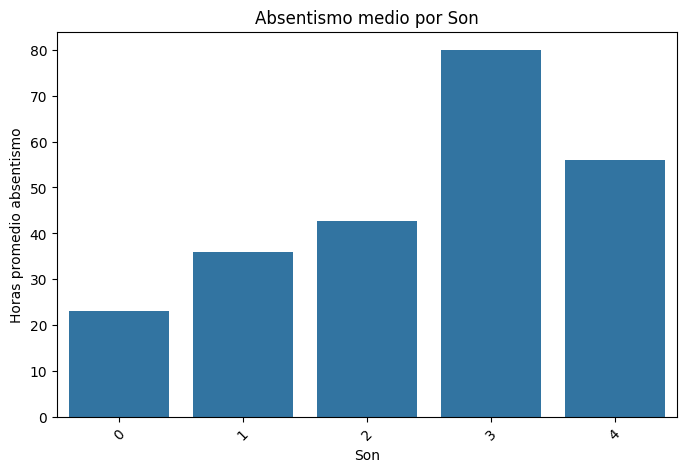

In [27]:
comparar_absentismo(df_empleados, 'Son')


 Recuento por grupo:
Pet
0    19
1     7
2     5
4     2
8     2
5     1
Name: count, dtype: int64

 Absentismo medio por grupo:
   Pet  Absenteeism_hours
1    1              50.29
0    0              38.11
2    2              28.80
3    4              24.00
4    5               8.00
5    8               4.00


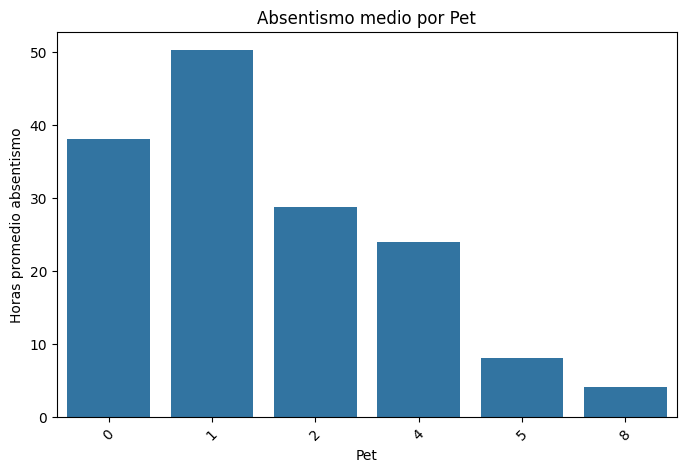

In [28]:
comparar_absentismo(df_empleados, 'Pet')

### Distancia al trabajo vs absentismo

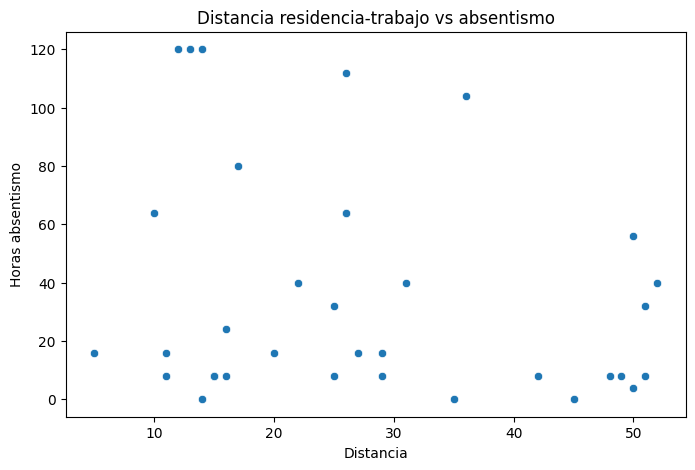

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_empleados,
    x='Distance_Residence_Work',
    y='Absenteeism_hours'
)

plt.title('Distancia residencia-trabajo vs absentismo')
plt.xlabel('Distancia')
plt.ylabel('Horas absentismo')

plt.show()

### Edad vs Absentismo - Boxplot

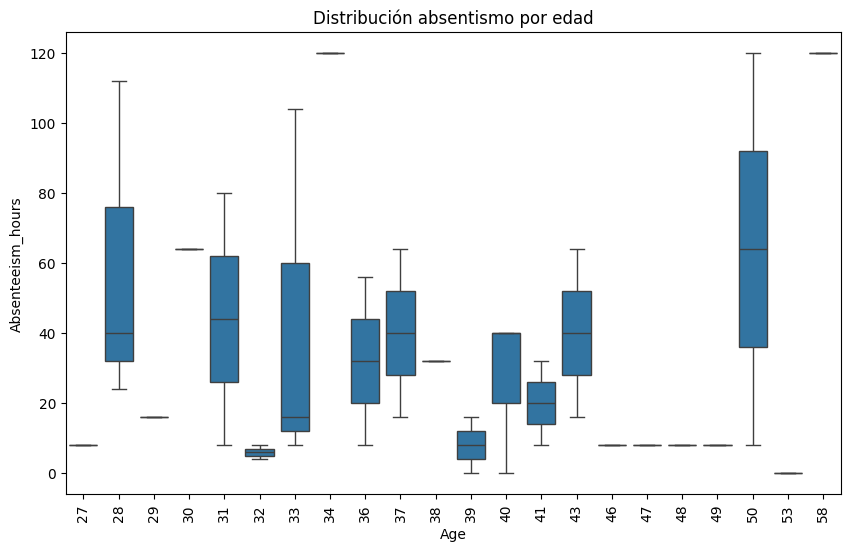

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_empleados,
    x='Age',
    y='Absenteeism_hours'
)

plt.title('Distribución absentismo por edad')

plt.xticks(rotation=90)

plt.show()

### Heatmap correlaciones

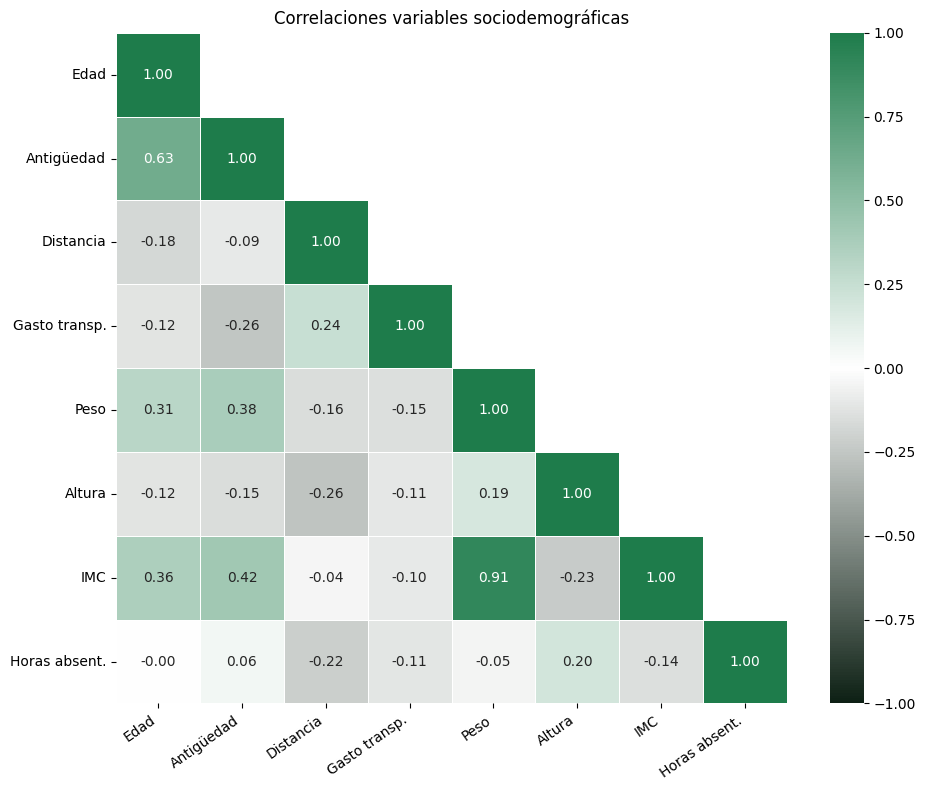

In [31]:
variables_corr = [
    'Age',
    'Service_time',
    'Distance_Residence_Work',
    'Transportation_expense',
    'Weight',
    'Height',
    'BMI_calculated',
    'Absenteeism_hours'
]

corr = df_empleados[variables_corr].corr()

# Etiquetas en español
labels_es = {
    'Age': 'Edad',
    'Service_time': 'Antigüedad',
    'Distance_Residence_Work': 'Distancia',
    'Transportation_expense': 'Gasto transp.',
    'Weight': 'Peso',
    'Height': 'Altura',
    'BMI_calculated': 'IMC',
    'Absenteeism_hours': 'Horas absent.'
}

corr = corr.rename(index=labels_es, columns=labels_es)

# Paleta verde con blanco en el centro
cmap_verde = LinearSegmentedColormap.from_list(
    'verde_blanco_verde',
    ["#0d2014", "#ffffff", "#1e7c4b"]
)

# Máscara para mostrar solo la mitad inferior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10, 8), facecolor='none')

ax = sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=cmap_verde,
    center=0,
    mask=mask,
    square=True,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_facecolor('none')

plt.title('Correlaciones variables sociodemográficas')

plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

    Interpretación:

1. Relaciones esperadas y consistentes

* **Peso y BMI (0.91)**: correlación muy alta y lógica, ya que el BMI depende directamente del peso y la altura, lo que valida la coherencia de los datos.

* **Edad y antigüedad (0.63)**: relación positiva clara, indicando que los empleados de mayor edad suelen tener más tiempo en la empresa, reflejando una plantilla progresivamente estable.


2. Patrones sociodemográficos relevantes

* **Edad / antigüedad y BMI (0.36–0.42)**: correlaciones moderadas que sugieren una posible tendencia a mayor índice de masa corporal en empleados de mayor edad o con más años en la empresa, lo que abre la puerta a políticas de bienestar y salud preventiva.

* **Distancia y gasto de transporte (0.24)**: relación débil, lo que indica que el coste de transporte no depende exclusivamente de la distancia, sino también de otros factores como el medio utilizado.


3. Relación con el absentismo

* El absentismo muestra **correlaciones muy débiles con casi todas las variables**.

* **Distancia (-0.22)**: relación negativa débil, indicando que vivir más lejos no implica necesariamente más absentismo.

* **Edad (0.00) y antigüedad (0.06)**: prácticamente sin relación lineal con las horas de ausencia.


    Conclusión general

El análisis sugiere que el absentismo no puede explicarse mediante relaciones lineales simples con variables individuales como edad, peso o distancia. Es necesario un analisis clustering

### Edad de fumadores/no fumadores

In [32]:
df_empleados.groupby('Social_smoker')[['Age', 'BMI_calculated', 'Absenteeism_hours']].mean().round(2)

,Age,BMI_calculated,Absenteeism_hours
Social_smoker,,,
0,37.90,26.85,38.76
1,40.14,24.57,22.86


### Edad de consumen/no consumen alcohol

In [33]:
df_empleados.groupby('Social_drinker')[['Age', 'BMI_calculated', 'Absenteeism_hours']].mean().round(2)

,Age,BMI_calculated,Absenteeism_hours
Social_drinker,,,
0,39.18,25.66,30.59
1,37.58,27.07,40.21


## 2. ANALISIS POR VARIABLES

### Segmentación perfiles por edad

In [34]:
def clasificar_edad(edad):

    if edad < 30:
        return 'Joven'
    
    elif edad < 45:
        return 'Adulto'
    
    else:
        return 'Senior'


df_empleados['Perfil_edad'] = df_empleados['Age'].apply(clasificar_edad)


 Recuento por grupo:
Perfil_edad
Adulto    23
Senior     8
Joven      5
Name: count, dtype: int64

 Absentismo medio por grupo:
  Perfil_edad  Absenteeism_hours
1       Joven              40.00
2      Senior              35.00
0      Adulto              34.96


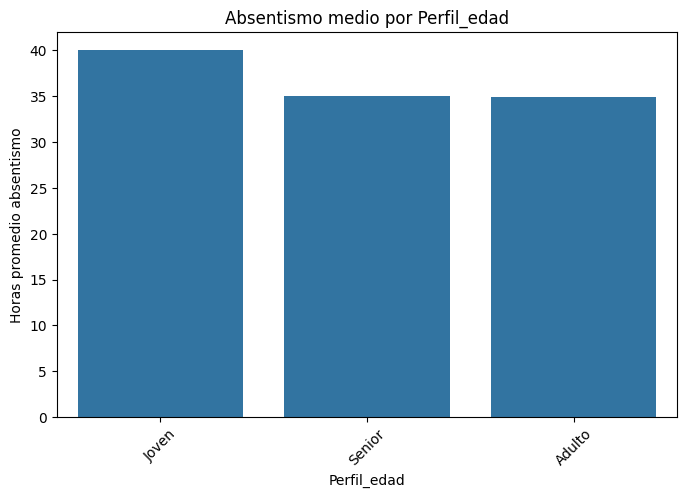

In [35]:
comparar_absentismo(df_empleados, 'Perfil_edad')

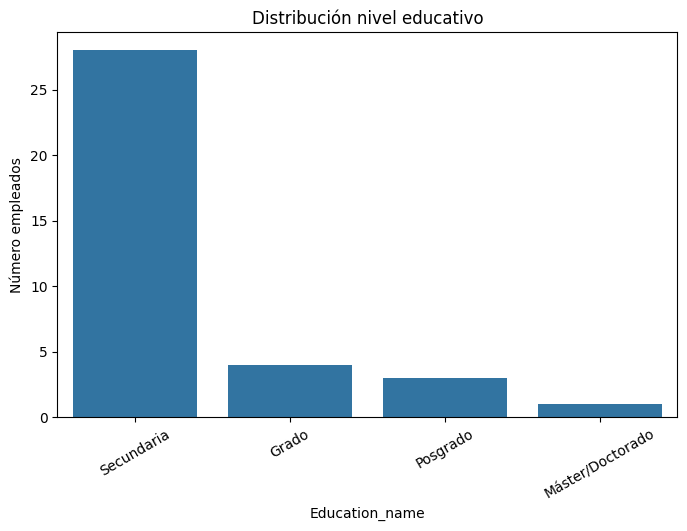

In [36]:
educacion = df_empleados['Education_name'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=educacion.index,
    y=educacion.values
)

plt.title('Distribución nivel educativo')
plt.ylabel('Número empleados')

plt.xticks(rotation=30)

plt.show()

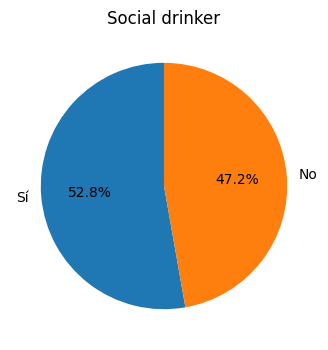

In [37]:
drinker = df_empleados['Social_drinker'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    drinker.values,
    labels=['Sí', 'No'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Social drinker')

plt.show()

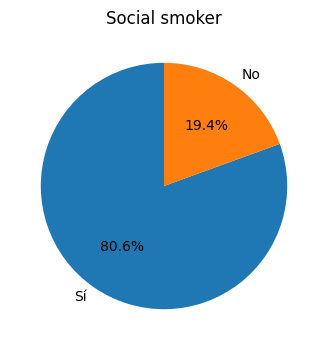

In [38]:
smoker = df_empleados['Social_smoker'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    smoker.values,
    labels=['Sí', 'No'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Social smoker')

plt.show()

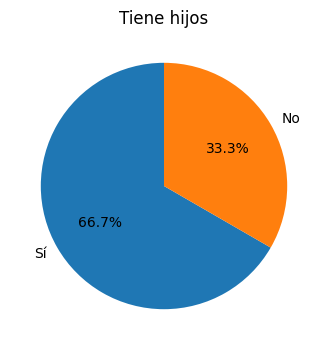

In [39]:
df_empleados['Has_children'] = df_empleados['Son'].apply(lambda x: 'Sí' if x > 0 else 'No')

children = df_empleados['Has_children'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    children.values,
    labels=children.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Tiene hijos')
plt.show()

plt.show()

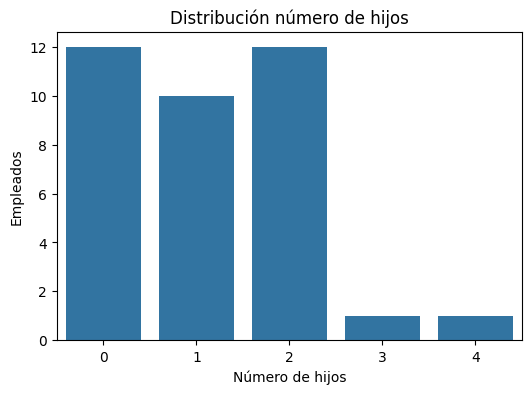

In [40]:
sons = df_empleados['Son'].value_counts().sort_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x=sons.index,
    y=sons.values
)

plt.title('Distribución número de hijos')
plt.xlabel('Número de hijos')
plt.ylabel('Empleados')

plt.show()

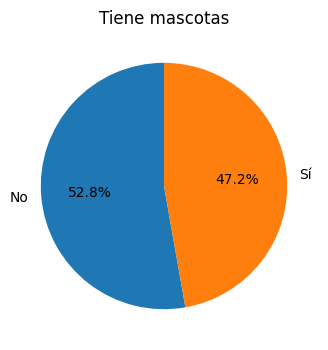

In [41]:
df_empleados['Has_pet'] = df_empleados['Pet'].apply(lambda x: 'Sí' if x > 0 else 'No')

pets = df_empleados['Has_pet'].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
    pets.values,
    labels=pets.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Tiene mascotas')
plt.show()

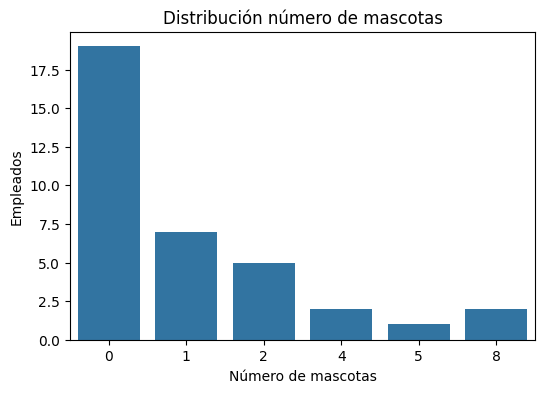

In [42]:
pets = df_empleados['Pet'].value_counts().sort_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x=pets.index,
    y=pets.values
)

plt.title('Distribución número de mascotas')
plt.xlabel('Número de mascotas')
plt.ylabel('Empleados')

plt.show()

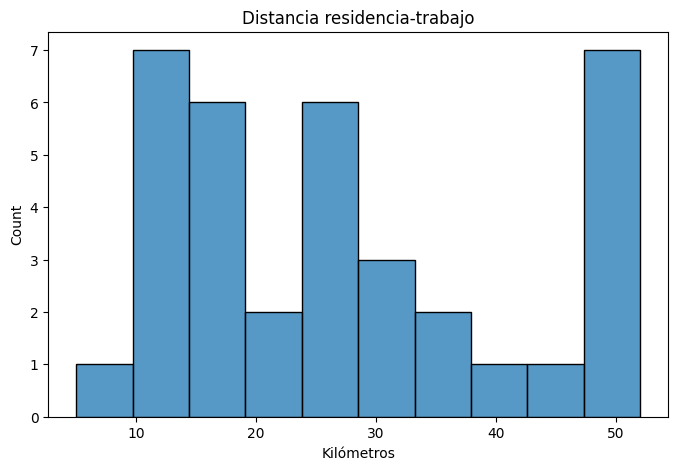

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['Distance_Residence_Work'], bins=10)

plt.title('Distancia residencia-trabajo')
plt.xlabel('Kilómetros')

plt.show()

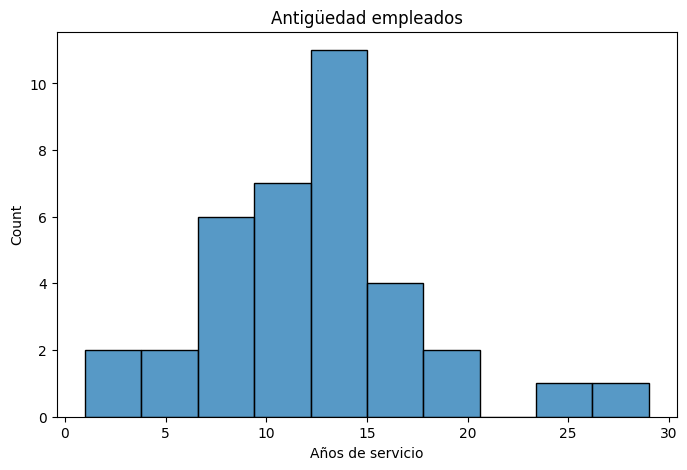

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['Service_time'], bins=10)

plt.title('Antigüedad empleados')
plt.xlabel('Años de servicio')

plt.show()

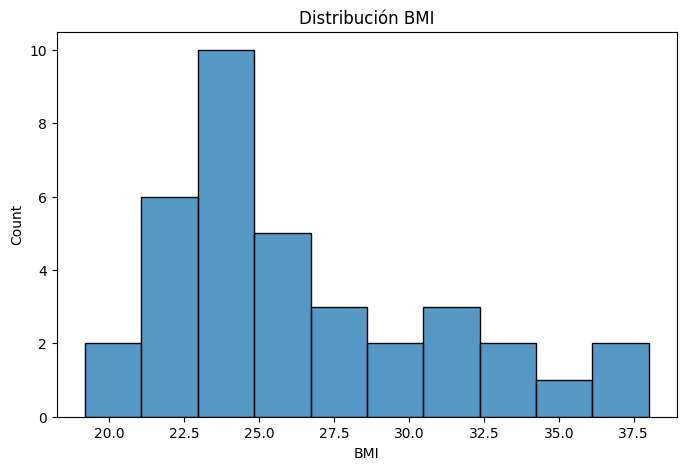

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(df_empleados['BMI_calculated'], bins=10)

plt.title('Distribución BMI')
plt.xlabel('BMI')

plt.show()

# Clustering

Seleccionar variables

In [46]:
features = [
    'Age',
    'Service_time',
    'Distance_Residence_Work',
    'Transportation_expense',
    'Education',
    'Son',
    'Pet',
    'BMI_calculated'
]

In [47]:
x = df_perfil[features]

In [48]:
x.columns

Index(['Age', 'Service_time', 'Distance_Residence_Work',
       'Transportation_expense', 'Education', 'Son', 'Pet', 'BMI_calculated'],
      dtype='str')

Escalar

In [49]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

Decidir nombre de grups (k)

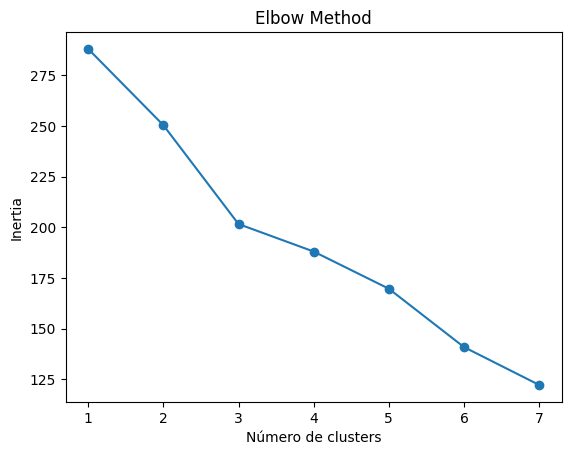

In [50]:
inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [51]:
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f'K={k}: {score:.3f}')

K=2: 0.203
K=3: 0.159
K=4: 0.106
K=5: 0.118
K=6: 0.141
K=7: 0.160


PCA

In [52]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

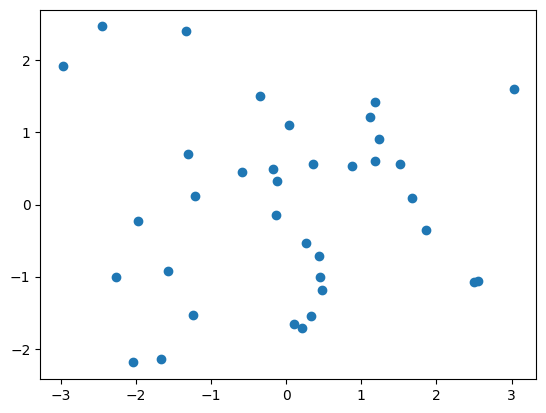

In [53]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

Con menos variables:

In [54]:
features_2 = [
    'Age',
    'Service_time',
    'Education',
    'Son',
    'Pet'
]

In [55]:
x_2 = df_perfil[features_2]

In [56]:
x_2.columns

Index(['Age', 'Service_time', 'Education', 'Son', 'Pet'], dtype='str')

Escalar

In [57]:
scaler = StandardScaler()

X_scaled_2 = scaler.fit_transform(x_2)

Decidir nombre de grups (k)

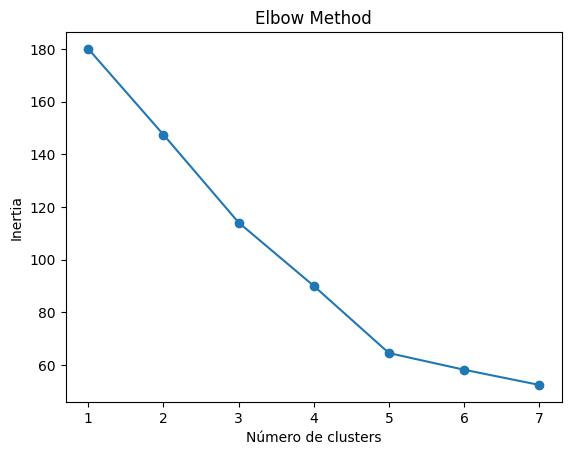

In [58]:
inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_2)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Busques el punt on la corba deixa de baixar fortament.

In [59]:
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled_2)

    score = silhouette_score(
        X_scaled_2,
        labels
    )

    print(f'K={k}: {score:.3f}')

K=2: 0.254
K=3: 0.219
K=4: 0.243
K=5: 0.273
K=6: 0.244
K=7: 0.237


Els silhouette scores solen interpretar-se així (aproximadament):

- 0.70 → excel·lent
- 0.50 - 0.70 → bo
- 0.25 - 0.50 → acceptable
- < 0.25 → separació feble

Mesura:
- cohesió dins del cluster,
- separació respecte als altres clusters.

Va de:
- -1 → molt dolent
- 0 → clusters superposats
- +1 → molt bona separació

PCA

In [60]:
pca = PCA(n_components=2)

X_pca_2 = pca.fit_transform(X_scaled_2)

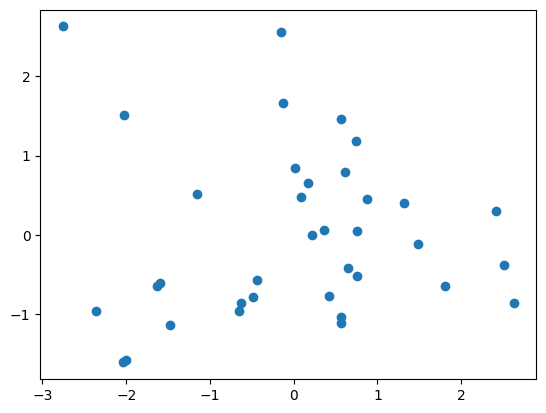

In [61]:
plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1]
)

Evaluación PCA

In [62]:
pca = PCA()

pca.fit(X_scaled)

print(pca.explained_variance_ratio_)

[0.27123273 0.19316747 0.14262707 0.11929281 0.10152578 0.07752794
 0.06719577 0.02743043]


In [63]:
print(pca.explained_variance_ratio_.cumsum())

[0.27123273 0.4644002  0.60702727 0.72632008 0.82784586 0.9053738
 0.97256957 1.        ]


In [64]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)

print(loadings)

                              PC1       PC2       PC3       PC4       PC5  \
Age                      0.558712  0.041244 -0.048047  0.039839  0.177381   
Service_time             0.590311 -0.036772 -0.106987 -0.081547  0.014260   
Distance_Residence_Work -0.169768  0.600069  0.036287 -0.313234 -0.135464   
Transportation_expense  -0.233201  0.349040 -0.398878  0.082615  0.777464   
Education               -0.213962 -0.452878  0.258574  0.473077  0.305548   
Son                      0.165402  0.231505 -0.500590  0.686815 -0.309253   
Pet                     -0.075489  0.467338  0.563758  0.436372 -0.127995   
BMI_calculated           0.421109  0.194774  0.436522  0.029754  0.374368   

                              PC6       PC7       PC8  
Age                      0.077883  0.675324 -0.434340  
Service_time             0.442379 -0.126837  0.648147  
Distance_Residence_Work  0.630907 -0.100101 -0.291977  
Transportation_expense  -0.053909  0.076317  0.211372  
Education                0

Modelo 3, menos variables

In [65]:
features_3 = [
    'Age',
    'Service_time',
    'Education'
]

In [66]:
x_3 = df_perfil[features_3]

In [67]:
x_3.columns

Index(['Age', 'Service_time', 'Education'], dtype='str')

Escalar

In [68]:
scaler = StandardScaler()

X_scaled_3 = scaler.fit_transform(x_3)

Decidir nombre de grups (k)

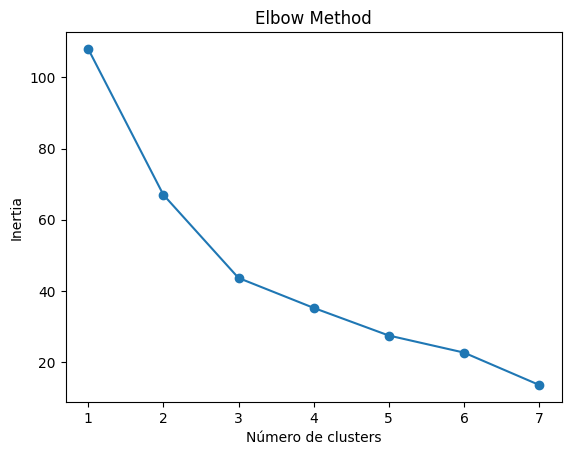

In [69]:
inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_3)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [70]:
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled_3)

    score = silhouette_score(
        X_scaled_3,
        labels
    )

    print(f'K={k}: {score:.3f}')

K=2: 0.406
K=3: 0.348
K=4: 0.349
K=5: 0.300
K=6: 0.325
K=7: 0.397


PCA k= 2

In [71]:
pca = PCA(n_components=2)

X_pca_3 = pca.fit_transform(X_scaled_3)

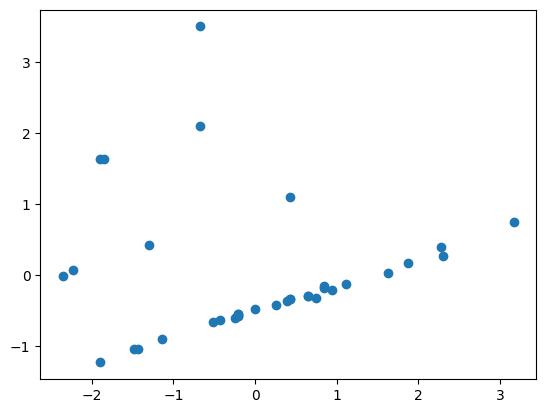

In [72]:
plt.scatter(
    X_pca_3[:,0],
    X_pca_3[:,1]
)

PCA k= 3

In [73]:
pca = PCA(n_components=3)

X_pca_3_2 = pca.fit_transform(X_scaled_3)

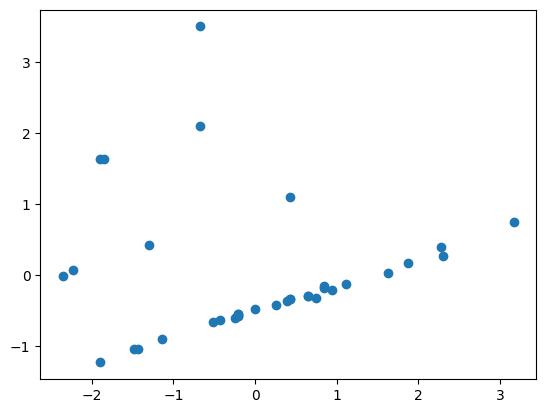

In [74]:
plt.scatter(
    X_pca_3_2[:,0],
    X_pca_3_2[:,1]
)

In [75]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled_3)

In [76]:
df_perfil['cluster_k2'] = KMeans(
    n_clusters=2,
    random_state=42
).fit_predict(X_scaled_3)

df_perfil['cluster_k3'] = KMeans(
    n_clusters=3,
    random_state=42
).fit_predict(X_scaled_3)

<Axes: >

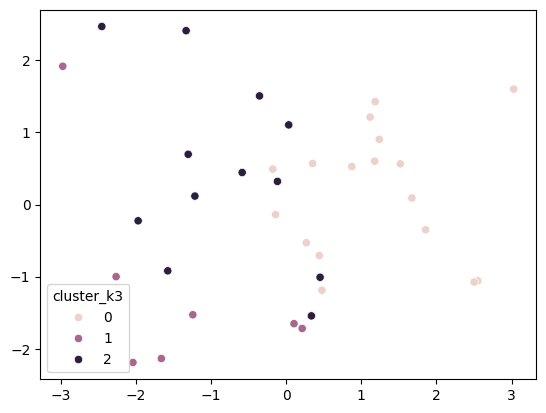

In [77]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df_perfil['cluster_k3']
)

In [78]:
df_perfil.groupby('cluster_k3').agg({
    'Age':'mean',
    'Service_time':'mean',
    'Education':'mean'
}).round(2)

,Age,Service_time,Education
cluster_k3,,,
0,44.94,15.65,1.06
1,33.14,8.43,2.71
2,32.00,10.08,1.00


<Axes: >

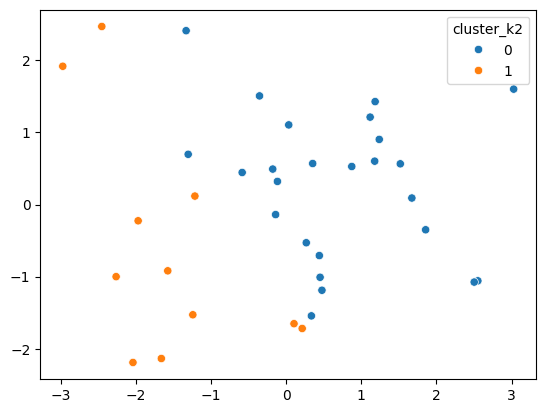

In [79]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df_perfil['cluster_k2']
)

In [80]:
df_perfil.groupby('cluster_k2').agg({
    'Age':'mean',
    'Service_time':'mean',
    'Education':'mean'
}).round(2)

,Age,Service_time,Education
cluster_k2,,,
0,41.44,14.48,1.04
1,31.27,7.64,2.09


**Vemos dos perfiles diferenciados**

In [81]:
df_perfil_abs_cluster = df_perfil.merge(
    df,
    on='ID',
    how='left'
)

In [82]:
df_abs_count = (
    df_perfil_abs_cluster
    .groupby('ID')
    .size()
    .reset_index(name='num_absences')
)

In [83]:
df_cluster = df_perfil_abs_cluster.merge(
    df_abs_count,
    on='ID'
)

In [84]:
df_cluster

,ID,Transportation_expense_x,Distance_Residence_Work_x,Service_time_x,Age_x,Education_x,Education_name_x,Son_x,Social_drinker_x,Social_smoker_x,...,Son_y,Social_drinker_y,Social_smoker_y,Pet_y,Weight_y,Height_y,Body_mass_index,BMI_calculated_y,Absenteeism_hours,num_absences
0,14,155,12,14,34,1,Secundaria,2,1,0,...,2,1,0,0,95,196,25,24.7,120,29
1,14,155,12,14,34,1,Secundaria,2,1,0,...,2,1,0,0,95,196,25,24.7,80,29
2,14,155,12,14,34,1,Secundaria,2,1,0,...,2,1,0,0,95,196,25,24.7,48,29
3,14,155,12,14,34,1,Secundaria,2,1,0,...,2,1,0,0,95,196,25,24.7,40,29
4,14,155,12,14,34,1,Secundaria,2,1,0,...,2,1,0,0,95,196,25,24.7,32,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,19,291,50,12,32,1,Secundaria,0,1,0,...,0,1,0,0,65,169,23,22.8,0,3
736,8,231,35,14,39,1,Secundaria,2,1,0,...,2,1,0,2,100,170,35,34.6,0,2
737,8,231,35,14,39,1,Secundaria,2,1,0,...,2,1,0,2,100,170,35,34.6,0,2
738,4,118,14,13,40,1,Secundaria,1,1,0,...,1,1,0,8,98,170,34,33.9,0,1


In [85]:
df_cluster.groupby('cluster_k2').agg({
    'num_absences':'mean',
    'Absenteeism_hours':'mean',
    'Hit_target':'mean'
    })

,num_absences,Absenteeism_hours,Hit_target
cluster_k2,,,
0,49.085271,7.612403,94.389535
1,43.205357,5.339286,95.044643


In [86]:
df_employee_cluster = (
    df_cluster
    .groupby('ID')
    .agg({
        'cluster_k2':'first',
        'Age_x':'first',
        'Service_time_x':'first',
        'Education_x':'first',
        'Son_x':'first',
        'Pet_x':'first',
        'Social_smoker_x':'first',
        'Social_drinker_x':'first',
        'BMI_calculated_x':'first',
        'Absenteeism_hours':'first',
        'Hit_target':'first'
    })
    .reset_index()
)

In [87]:
df_employee_cluster.shape

(36, 12)

## Descriptivos 2 grupos

In [88]:
df_employee_cluster.groupby('cluster_k2').agg(
    ['mean','median','min','max']
).round(2)

ID                 Age_x                Service_time_x         \
             mean median min max   mean median min max           mean median   
cluster_k2                                                                     
0           17.72   16.0   2  36  41.44   40.0  31  58          14.48   13.0   
1           20.27   22.0   1  30  31.27   30.0  27  41           7.64    8.0   

            ... BMI_calculated_x       Absenteeism_hours                  \
            ...              min   max              mean median min  max   
cluster_k2  ...                                                            
0           ...             21.5  38.0             38.88   16.0   0  120   
1           ...             19.2  29.7             28.36   16.0   8  112   

           Hit_target                 
                 mean median min max  
cluster_k2                            
0               94.68   96.0  81  99  
1               94.18   94.0  88  99  

[2 rows x 44 columns]

In [89]:
df_habits = (
    df_cluster
    .groupby('ID')
    .agg({
        'cluster_k2': 'first',
        'Social_smoker_x': 'first',
        'Social_drinker_x': 'first',
        'Pet_x':'first',
        'Son_x':'first'
    })
    .reset_index()
)

In [90]:
df_habits['cluster_k2'].value_counts()

cluster_k2
0    25
1    11
Name: count, dtype: int64

## Social drinker y smoker

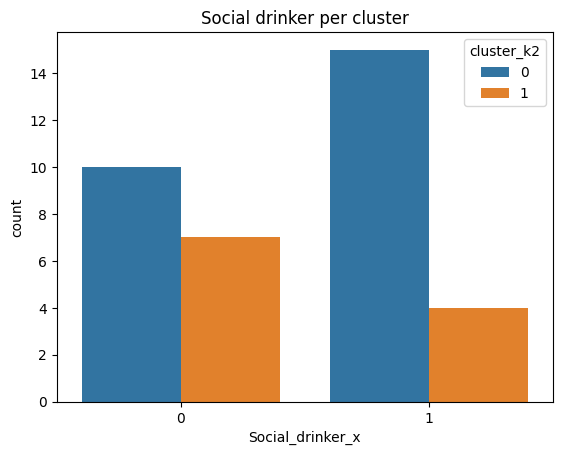

In [91]:
sns.countplot(
    data=df_habits,
    x='Social_drinker_x',
    hue='cluster_k2'
)

plt.title('Social drinker per cluster')
plt.show()

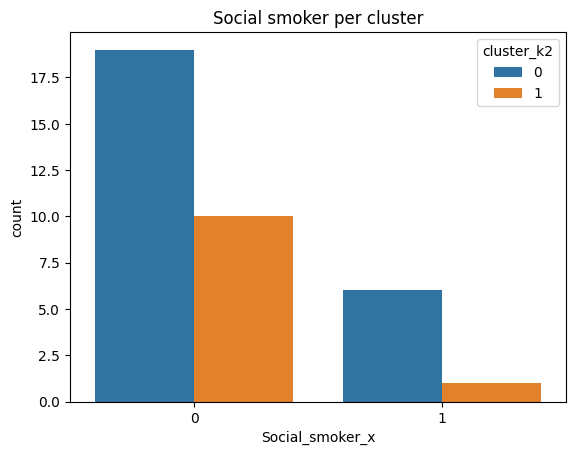

In [92]:
sns.countplot(
    data=df_habits,
    x='Social_smoker_x',
    hue='cluster_k2'
)

plt.title('Social smoker per cluster')
plt.show()

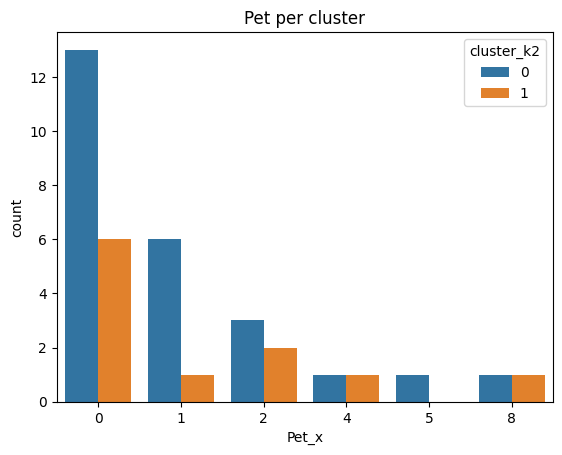

In [93]:
sns.countplot(
    data=df_habits,
    x='Pet_x',
    hue='cluster_k2'
)

plt.title('Pet per cluster')
plt.show()

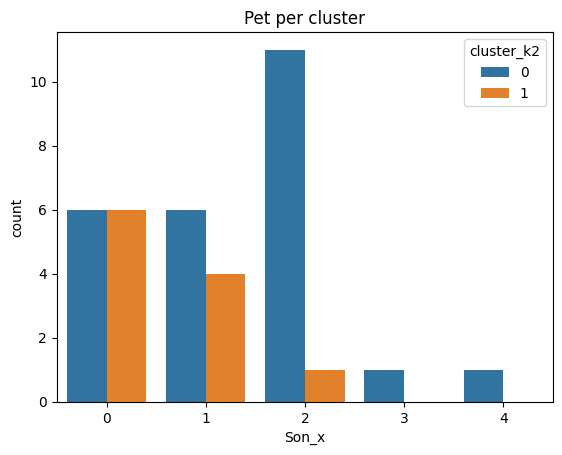

In [94]:
sns.countplot(
    data=df_habits,
    x='Son_x',
    hue='cluster_k2'
)

plt.title('Pet per cluster')
plt.show()

**Estos perfiles no reflejan diferencias por lo que respecta a las horas de absentismo ni al hit_target ni con el número de solicitudes que realizan (diferencias pequeñas)**

In [95]:
pd.crosstab(
    df_perfil_abs_cluster['cluster_k2'],
    df_perfil_abs_cluster['Reason_absence_name'],
    normalize='index'
).round(3) * 100

Reason_absence_name,Afecciones perinatales,Ausencia injustificada,Consulta dental,Consulta médica,Donación de sangre,"Embarazo, parto y puerperio","Endocrinas, nutricionales y metabólicas",Enfermedades infecciosas y parasitarias,Examen de laboratorio,Factores de salud y contacto sanitario,...,Sangre e inmunidad,Seguimiento de paciente,Sistema circulatorio,Sistema digestivo,Sistema genitourinario,Sistema musculoesquelético,Sistema nervioso,Sistema respiratorio,Síntomas y hallazgos no clasificados,Trastornos mentales y del comportamiento
cluster_k2,,,,,,,,,,,,,,,,,,,,,
0,0.4,6.0,20.2,18.3,0.6,0.4,0.4,1.9,3.3,0.8,...,0.2,4.0,0.6,3.5,3.1,7.5,1.0,4.2,3.1,0.6
1,0.5,1.8,6.9,28.1,0.0,0.0,0.0,3.2,6.9,0.9,...,0.0,8.8,0.5,4.1,1.8,8.8,1.4,2.3,2.8,0.0


In [96]:
for cluster in sorted(df_perfil_abs_cluster['cluster_k2'].unique()):

    print(f"\nCLUSTER {cluster}")

    print(
        df_perfil_abs_cluster
        .loc[
            df_perfil_abs_cluster['cluster_k2'] == cluster,
            'Reason_absence_name'
        ]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .head(10)
    )


CLUSTER 0
Reason_absence_name
Consulta dental                                      20.2
Consulta médica                                      18.3
Fisioterapia                                         10.4
Sistema musculoesquelético                            7.5
Ausencia injustificada                                6.0
Lesiones, intoxicaciones y consecuencias externas     5.8
Sistema respiratorio                                  4.2
Seguimiento de paciente                               4.0
Sistema digestivo                                     3.5
Examen de laboratorio                                 3.3
Name: proportion, dtype: float64

CLUSTER 1
Reason_absence_name
Consulta médica                                      28.1
Sistema musculoesquelético                            8.8
Seguimiento de paciente                               8.8
Fisioterapia                                          8.8
Examen de laboratorio                                 6.9
Consulta dental                    

In [97]:
df_perfil_abs_cluster[
    ['Age_x','Service_time_x','Education_x',
     'Absenteeism_hours','Hit_target']
].corr()

,Age_x,Service_time_x,Education_x,Absenteeism_hours,Hit_target
Age_x,1.000000,0.670979,-0.221882,0.065760,-0.039224
Service_time_x,0.670979,1.000000,-0.213000,0.019029,-0.007840
Education_x,-0.221882,-0.213000,1.000000,-0.046235,0.101062
Absenteeism_hours,0.065760,0.019029,-0.046235,1.000000,0.026695
Hit_target,-0.039224,-0.007840,0.101062,0.026695,1.000000


In [98]:
df_perfil_abs_cluster

,ID,Transportation_expense_x,Distance_Residence_Work_x,Service_time_x,Age_x,Education_x,Education_name_x,Son_x,Social_drinker_x,Social_smoker_x,...,Education_name_y,Son_y,Social_drinker_y,Social_smoker_y,Pet_y,Weight_y,Height_y,Body_mass_index,BMI_calculated_y,Absenteeism_hours
0,14,155,12,14,34,1,Secundaria,2,1,0,...,Secundaria,2,1,0,0,95,196,25,24.7,120
1,14,155,12,14,34,1,Secundaria,2,1,0,...,Secundaria,2,1,0,0,95,196,25,24.7,80
2,14,155,12,14,34,1,Secundaria,2,1,0,...,Secundaria,2,1,0,0,95,196,25,24.7,48
3,14,155,12,14,34,1,Secundaria,2,1,0,...,Secundaria,2,1,0,0,95,196,25,24.7,40
4,14,155,12,14,34,1,Secundaria,2,1,0,...,Secundaria,2,1,0,0,95,196,25,24.7,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,19,291,50,12,32,1,Secundaria,0,1,0,...,Secundaria,0,1,0,0,65,169,23,22.8,0
736,8,231,35,14,39,1,Secundaria,2,1,0,...,Secundaria,2,1,0,2,100,170,35,34.6,0
737,8,231,35,14,39,1,Secundaria,2,1,0,...,Secundaria,2,1,0,2,100,170,35,34.6,0
738,4,118,14,13,40,1,Secundaria,1,1,0,...,Secundaria,1,1,0,8,98,170,34,33.9,0
